# Notebook 01 — `train_ppo_baseline`

Train standard PPO on MountainCar-v0 and create the reusable trajectory and
checkpoint dataset that Notebooks 02–06 consume.

**Plan requirements**

- Inputs: MountainCar-v0, fixed PPO config, 3 seeds.
- Save observations, actions, rewards, next states, done flags, log-probs, policy
  probabilities, values, episode/timestep IDs.
- Save checkpoints at ~10%, 30%, 50%, 75%, 100%.
- Outputs: return curve, entropy, KL, losses, trajectories, checkpoints.
- **CHECK:** PPO learns at least partially; data and checkpoints reload correctly.

This notebook is a thin driver. All logic lives in `config/`, `envs/`, `agents/`,
`dataio/`, `utils/`, `scripts/`. Change hyperparameters in `config/config.py`,
never here.

Runtime: ~85 s per seed on CPU, ~4.5 minutes for all three.

## 0. Setup

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "config").is_dir():          # notebook launched from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

from config import DEFAULT, RUNS_DIR, FIGURES_DIR, seed_dir
from dataio import load_trajectories, validate, load_checkpoint, list_checkpoints
from utils.logging import read_scalars
from utils.plotting import (
    plot_learning_curves, plot_episode_returns, plot_grid,
    plot_state_visitation, savefig,
)

FIG = FIGURES_DIR / "nb01"
FIG.mkdir(parents=True, exist_ok=True)
print("project root:", ROOT)

project root: /home/claude/PPO_CF


## 1. Configuration

Single source of truth: `config/config.py`.

In [2]:
cfg = DEFAULT
print(cfg.summary())

env                MountainCar-v0  (n_envs=16, obs_norm=fixed)
total_timesteps    400,000  per seed
rollout batch      512  (16 envs x 32 steps)
updates            781
minibatch size     128  x 4 epochs
gamma / lambda     0.99 / 0.98
lr                 0.0007  (anneal=True)
ent_coef           0.003
seeds              [0, 1, 2]
checkpoints at     ['10%', '30%', '50%', '75%', '100%']


### Why these settings

Four choices were forced by measurement rather than taste. Each is documented
inline in `config/config.py`; the short version:

1. **Actor and critic gradients are clipped separately.** All MountainCar rewards
   are −1, so the value loss is O(10³) from the first update. A single global
   grad-norm clip lets the critic dominate the norm, rescaling the whole gradient
   by ~1/40 — the policy then never moves (entropy pinned at log 3, KL ~1e-6).

2. **`max_episode_steps = 500` during training, evaluated at the standard 200.**
   At the registered 200-step limit the first goal reach takes >500k steps. At
   500 it takes ~130–220k. The resulting policy is then scored under the standard
   200-step limit, so the benchmark is not softened.

3. **Adaptive entropy floor, not a fixed `ent_coef`.** Reaching the goal requires
   *temporally correlated* actions: a uniform random policy succeeds in 0 of 2000
   episodes (best position −0.17 vs goal +0.50), while a sticky policy succeeds
   ~10% of the time. High `ent_coef` pins the policy near uniform, where success
   probability is zero; `ent_coef=0` collapses it to a deterministic bad policy
   before it sees any reward, which is irrecoverable.

4. **The entropy anneal is event-based.** The floor is held until the first goal
   reach, then decays. A wall-clock schedule sharpens the policy before there is
   anything worth sharpening towards.

## 2. Train

Set `FORCE_RETRAIN = True` to overwrite existing runs.

In [3]:
from scripts.train_baseline import run_seeds

FORCE_RETRAIN = False

run_dir = RUNS_DIR / cfg.run.run_name
already = all((seed_dir(cfg.run.run_name, s) / "trajectories.npz").exists() for s in cfg.run.seeds)

if already and not FORCE_RETRAIN:
    print(f"found existing run at {run_dir} — skipping training")
    print("set FORCE_RETRAIN = True to re-run")
else:
    results = run_seeds(cfg)

found existing run at /home/claude/PPO_CF/runs/nb01_baseline — skipping training
set FORCE_RETRAIN = True to re-run


## 3. Load outputs

In [4]:
scalars  = {s: read_scalars(seed_dir(cfg.run.run_name, s) / "scalars.csv")  for s in cfg.run.seeds}
episodes = {s: pd.read_csv(seed_dir(cfg.run.run_name, s) / "episodes.csv")  for s in cfg.run.seeds}

summary = pd.DataFrame({
    "first_goal_reach": {s: (int(e.loc[e['success'], 'global_step'].iloc[0])
                             if e['success'].any() else None) for s, e in episodes.items()},
    "final_return":     {s: d['mean_return_100'].iloc[-1]      for s, d in scalars.items()},
    "final_success":    {s: d['success_rate_100'].iloc[-1]     for s, d in scalars.items()},
    "final_entropy":    {s: d['entropy'].iloc[-1]              for s, d in scalars.items()},
    "final_expl_var":   {s: d['explained_variance'].iloc[-1]   for s, d in scalars.items()},
    "episodes":         {s: len(e)                             for s, e in episodes.items()},
})
summary.index.name = "seed"
summary.round(3)

,first_goal_reach,final_return,final_success,final_entropy,final_expl_var,episodes
seed,,,,,,
0,164464,-134.61,1.0,0.151,0.948,1774
1,157712,-136.13,1.0,0.117,0.968,1882
2,220496,-229.68,1.0,0.520,0.955,1150


## 4. Return curve

Plan output #1: PPO return vs environment steps.

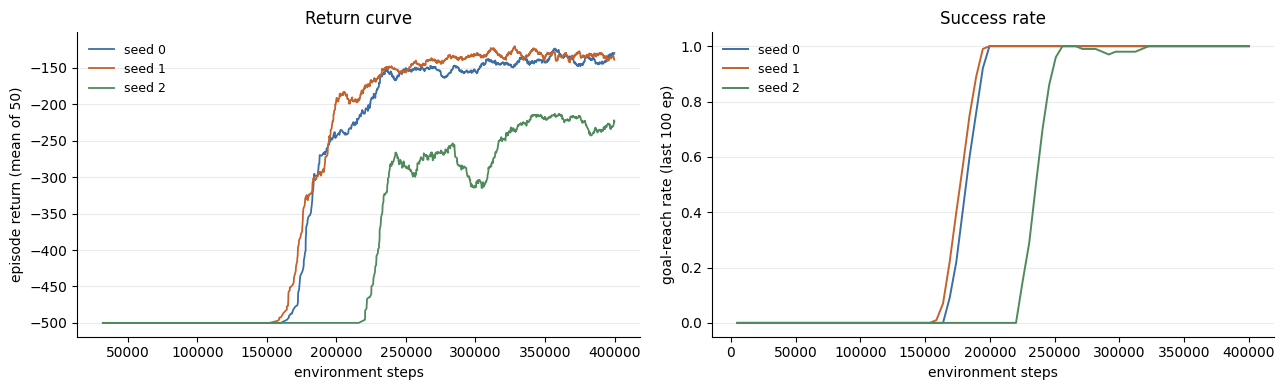

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_episode_returns(episodes, window=50, ax=axes[0])
plot_learning_curves(scalars, y="success_rate_100",
                     ylabel="goal-reach rate (last 100 ep)",
                     title="Success rate", ax=axes[1])
axes[1].set_ylim(-0.05, 1.05)
fig.tight_layout()
savefig(fig, FIG / "return_curve.png")
plt.show()

## 5. Optimisation diagnostics

Plan outputs #8 and the loss/entropy/KL requirement.

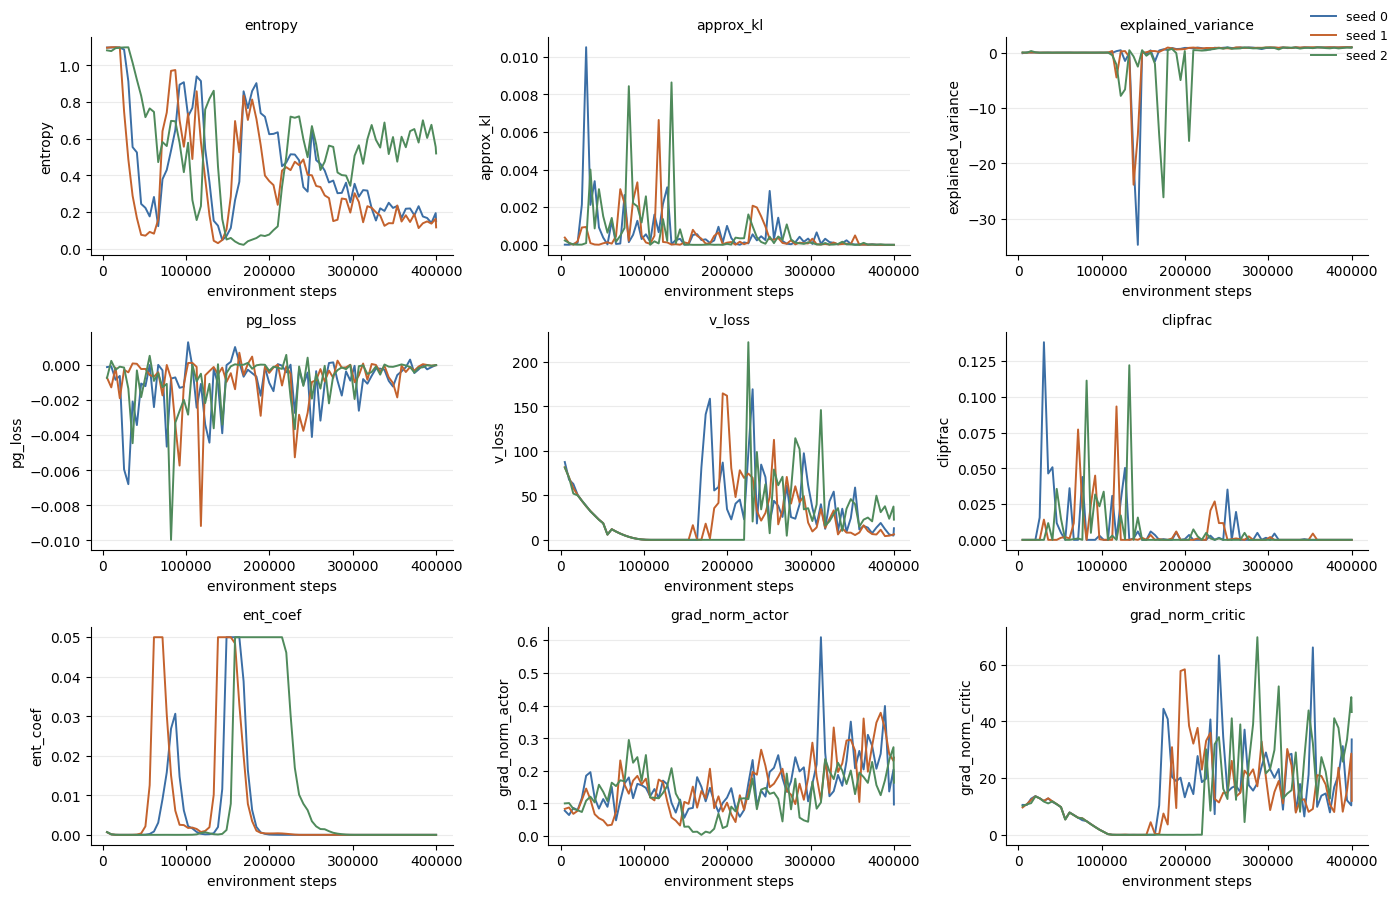

In [6]:
fig = plot_grid(scalars, [
    "entropy", "approx_kl", "explained_variance",
    "pg_loss", "v_loss", "clipfrac",
    "ent_coef", "grad_norm_actor", "grad_norm_critic",
], ncols=3, figsize=(14, 9))
savefig(fig, FIG / "diagnostics.png")
plt.show()

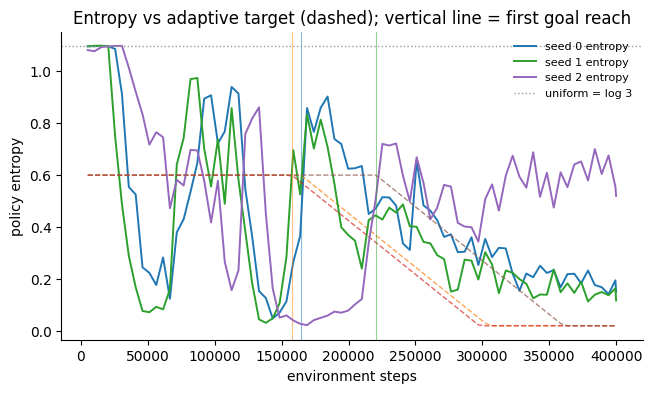

In [7]:
# The adaptive entropy controller: is the realised entropy tracking its target,
# and does the target start decaying only after the first goal reach?
fig, ax = plt.subplots(figsize=(7.5, 4))
for i, s in enumerate(sorted(scalars)):
    d = scalars[s]
    ax.plot(d["global_step"], d["entropy"], lw=1.4, label=f"seed {s} entropy")
    ax.plot(d["global_step"], d["entropy_target"], lw=1.0, ls="--", alpha=0.7)
    fs = summary.loc[s, "first_goal_reach"]
    if fs is not None:
        ax.axvline(fs, color=f"C{i}", lw=0.8, alpha=0.5)
ax.axhline(np.log(3), color="#999", lw=1, ls=":", label="uniform = log 3")
ax.set_xlabel("environment steps"); ax.set_ylabel("policy entropy")
ax.set_title("Entropy vs adaptive target (dashed); vertical line = first goal reach")
ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)
savefig(fig, FIG / "entropy_control.png")
plt.show()

## 6. CHECK — trajectory files reload and are structurally sound

`dataio.trajectory.validate` asserts the properties Notebooks 02–06 rely on:

- `probs` rows sum to 1 and `logprob == log probs[action]`
- `next_obs[t] == obs[t+1]` inside an episode (i.e. the recorded successor is the
  true successor, never a post-reset observation)
- no row is both terminated and truncated
- at most one terminal row per episode
- all observations and values finite

In [8]:
trajs, all_clean = {}, True
for s in cfg.run.seeds:
    p = seed_dir(cfg.run.run_name, s) / "trajectories.npz"
    trajs[s] = load_trajectories(p)
    print(f"seed {s}  ({p.stat().st_size/1e6:.1f} MB)")
    problems = validate(trajs[s], n_actions=trajs[s].n_actions)
    print("  ->", problems if problems else "NO PROBLEMS")
    all_clean &= not problems
    print()
print("TRAJECTORY VALIDATION:", "PASS" if all_clean else "FAIL")

seed 0  (25.0 MB)
  rows            399,872
  episodes        1,790
  terminated rows 1,446   (MountainCar: goal reached)
  truncated rows  328
  problems        0
  -> NO PROBLEMS



seed 1  (24.7 MB)
  rows            399,872
  episodes        1,898
  terminated rows 1,567   (MountainCar: goal reached)
  truncated rows  315
  problems        0
  -> NO PROBLEMS



seed 2  (25.2 MB)
  rows            399,872
  episodes        1,166
  terminated rows 711   (MountainCar: goal reached)
  truncated rows  439
  problems        0
  -> NO PROBLEMS

TRAJECTORY VALIDATION: PASS


In [9]:
# Every field the plan asks for is present, with its shape and dtype.
t = trajs[cfg.run.seeds[0]]
pd.DataFrame(
    [(k, str(v.shape), str(v.dtype)) for k, v in t.data.items() if not k.startswith("_")],
    columns=["field", "shape", "dtype"],
)

,field,shape,dtype
0,raw_obs,"(399872, 2)",float32
1,sim_state,"(399872, 2)",float64
2,action,"(399872,)",int8
3,reward,"(399872,)",float32
4,next_raw_obs,"(399872, 2)",float32
5,next_sim_state,"(399872, 2)",float64
6,terminated,"(399872,)",bool
7,truncated,"(399872,)",bool
8,logprob,"(399872,)",float32
9,probs,"(399872, 3)",float32


## 7. CHECK — checkpoints reload and the policy actually learned

Two things are being checked at once.

*Reload correctness:* a `Checkpoint` bundles the network **and** the observation
scaler, because the scaler sits between a simulator state and the network input.
NB02 restores raw simulator states and asks for π(·|s) and V(s); if the scaler
were not carried along, every downstream number would be silently wrong.

*Learning:* greedy rollouts under the **standard 200-step** MountainCar-v0 —
not the 500-step limit used for training.

In [10]:
def greedy_eval(ck, n_episodes=50, limit=200, seed0=90_000):
    env = gym.make("MountainCar-v0", max_episode_steps=limit)
    rets, succ = [], 0
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed0 + ep)
        total = 0.0
        while True:
            obs, r, term, trunc, _ = env.step(int(np.argmax(ck.probs(obs)[0])))
            total += r
            if term:
                succ += 1
                break
            if trunc:
                break
        rets.append(total)
    env.close()
    return float(np.mean(rets)), succ / n_episodes


rows = []
for s in cfg.run.seeds:
    for p in list_checkpoints(seed_dir(cfg.run.run_name, s) / "checkpoints"):
        ck = load_checkpoint(p)
        ret, sr = greedy_eval(ck)
        rows.append({"seed": s, "frac": f"{ck.fraction:.0%}", "step": ck.global_step,
                     "greedy_return_200": round(ret, 1), "greedy_success_200": sr})

FRAC_ORDER = [f"{f:.0%}" for f in cfg.run.checkpoint_fractions]
evaldf = pd.DataFrame(rows)
evaldf["frac"] = pd.Categorical(evaldf["frac"], categories=FRAC_ORDER, ordered=True)
evaldf.pivot(index="seed", columns="frac", values=["greedy_return_200", "greedy_success_200"])

greedy_return_200                             greedy_success_200       \
frac               10%    30%    50%    75%   100%                10%  30%   
seed                                                                         
0               -200.0 -200.0 -199.1 -140.2 -132.2                0.0  0.0   
1               -200.0 -200.0 -185.5 -133.0 -133.5                0.0  0.0   
2               -200.0 -200.0 -200.0 -200.0 -199.1                0.0  0.0   

                        
frac   50%   75%  100%  
seed                    
0     0.02  0.98  1.00  
1     0.24  1.00  1.00  
2     0.00  0.00  0.06

### Read this table before writing Notebook 02

The plan draws NB02's 500 evaluation states from the **~30% checkpoint**. On every
seed the 30% checkpoint has a greedy success rate of **0** — the first goal reach
happens at 39–55% of training, so at 30% the critic has never seen a reward and
V(s) is close to constant.

Since the oracle is `Q_CF(s,a) = r + γV(s')`, a near-constant V makes
`A_CF ≈ 0` for all three actions, and Gate 2 ("A_CF is nontrivial") would fail for
a reason unrelated to the method. The cell below quantifies how much room the
landscape actually has at each checkpoint. Options are recorded in
`experiment_plan.md` under "Open issue this notebook creates for Notebook 02".

In [11]:
# Proxy for Gate 2 headroom, computed WITHOUT the oracle: how much does V vary
# across the three one-step successor states reachable from each visited state?
# A_CF cannot be more informative than this spread, because r is identical (-1)
# for every non-terminal action in MountainCar.
from envs.env_pool import make_env, set_sim_state

def value_spread(ck, states, n=300, gamma=0.99):
    env = make_env("MountainCar-v0", max_episode_steps=500)
    q = np.zeros((n, 3))
    for i, st in enumerate(states[:n]):
        for a in range(3):
            set_sim_state(env, st)
            obs, r, term, trunc, _ = env.step(a)
            q[i, a] = r + (0.0 if term else gamma * float(ck.values(obs)[0]))
    env.close()
    pi = ck.probs(states[:n])
    v_pi = (pi * q).sum(1, keepdims=True)
    a_cf = q - v_pi
    return np.abs(a_cf).mean(), float(np.abs((pi * a_cf).sum(1)).max())

rng = np.random.default_rng(0)
rows = []
for s in cfg.run.seeds:
    tr = trajs[s]
    idx = rng.choice(len(tr), 300, replace=False)
    states = tr.sim_state[idx]
    for p in list_checkpoints(seed_dir(cfg.run.run_name, s) / "checkpoints"):
        ck = load_checkpoint(p)
        spread, centering_err = value_spread(ck, states)
        rows.append({"seed": s, "frac": f"{ck.fraction:.0%}",
                     "mean |A_CF|": round(spread, 4),
                     "max |sum pi*A|": round(centering_err, 8)})

spread_df = pd.DataFrame(rows)
spread_df["frac"] = pd.Categorical(spread_df["frac"], categories=FRAC_ORDER, ordered=True)
print("mean |A_CF| -- how far apart the three actions are. Near 0 => Gate 2 fails.")
print("max |sum pi*A| across all rows:", spread_df["max |sum pi*A|"].max(),
      "(centering identity; must be ~0 by construction)\n")
spread_df.pivot(index="seed", columns="frac", values="mean |A_CF|")

mean |A_CF| -- how far apart the three actions are. Near 0 => Gate 2 fails.
max |sum pi*A| across all rows: 1.138e-05 (centering identity; must be ~0 by construction)



frac,10%,30%,50%,75%,100%
seed,,,,,
0,0.0039,0.0021,0.2396,0.3646,0.4416
1,0.0221,0.0419,0.3694,0.4416,0.4522
2,0.0053,0.0102,0.0108,0.1779,0.2547


## 8. State visitation

NB02 samples 500 states to build the oracle on. They must come from a region the
policy actually visits, otherwise the landscape is measured off-distribution.

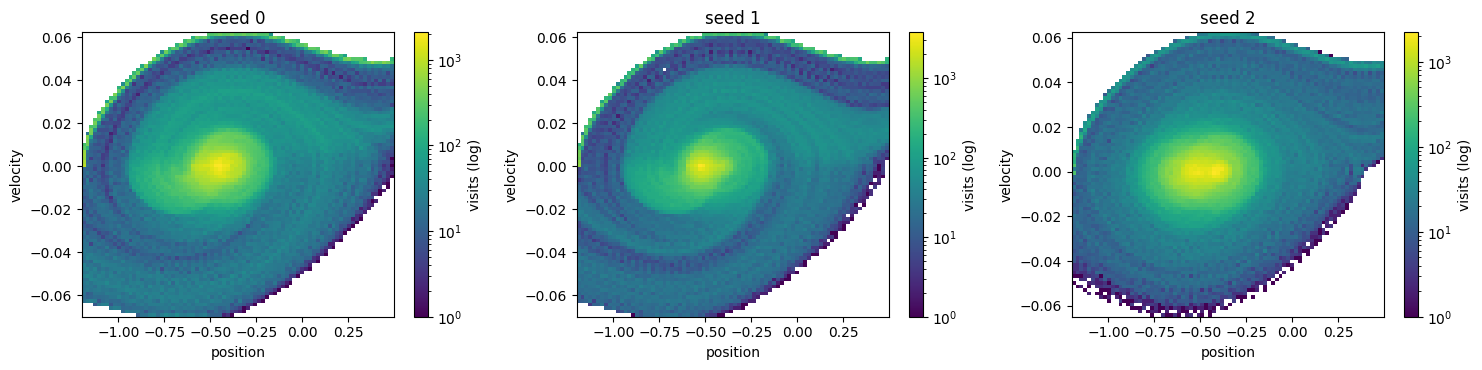

In [12]:
fig, axes = plt.subplots(1, len(cfg.run.seeds), figsize=(5 * len(cfg.run.seeds), 3.8))
for ax, s in zip(np.atleast_1d(axes), cfg.run.seeds):
    plot_state_visitation(trajs[s].raw_obs, ax=ax)
    ax.set_title(f"seed {s}")
fig.tight_layout()
savefig(fig, FIG / "state_visitation.png")
plt.show()

## 9. Gate 1 verdict

In [13]:
learned = {s: bool(episodes[s]["success"].any()) for s in cfg.run.seeds}
n_ck    = {s: len(list_checkpoints(seed_dir(cfg.run.run_name, s) / "checkpoints")) for s in cfg.run.seeds}

checks = {
    "all seeds reach the goal at least once": all(learned.values()),
    "all seeds end above chance (success rate > 0.5)":
        all(scalars[s]["success_rate_100"].iloc[-1] > 0.5 for s in cfg.run.seeds),
    "critic is informative (explained variance > 0.5)":
        all(scalars[s]["explained_variance"].iloc[-1] > 0.5 for s in cfg.run.seeds),
    "trajectory files reload and validate": all_clean,
    "5 checkpoints per seed, all reloadable": all(v == 5 for v in n_ck.values()),
}

width = max(len(k) for k in checks)
for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k:<{width}}")

print()
print("GATE 1:", "PASS — proceed to Notebook 02" if all(checks.values())
                 else "FAIL — do not proceed; debug the baseline first")

  PASS  all seeds reach the goal at least once          
  PASS  all seeds end above chance (success rate > 0.5) 
  PASS  critic is informative (explained variance > 0.5)
  PASS  trajectory files reload and validate            
  PASS  5 checkpoints per seed, all reloadable          

GATE 1: PASS — proceed to Notebook 02


---

## What Notebook 02 inherits

Per seed, in `runs/nb01_baseline/seed_<n>/`:

| artifact | contents |
|---|---|
| `trajectories.npz` | ~400k rows; `sim_state` and `next_sim_state` are stored explicitly so the oracle restores exact simulator states rather than trusting `obs == state` |
| `checkpoints/ckpt_*.pt` | weights **and** the frozen observation scaler, at 10/30/50/75/100% |
| `scalars.csv`, `episodes.csv`, `config.json` | diagnostics and the exact config used |

Interfaces NB02 should use, and nothing lower-level:

```python
from dataio import load_trajectories, load_checkpoint
from envs.env_pool import make_env, set_sim_state, get_sim_state

ck = load_checkpoint(".../ckpt_030.pt")
ck.probs(raw_obs)     # pi(.|s), scaler applied
ck.values(raw_obs)    # V(s),    scaler applied

env = make_env("MountainCar-v0", max_episode_steps=500)
obs = set_sim_state(env, sim_state)   # exact restore, TimeLimit counter reset
```

**Two things to settle before writing NB02**, both recorded in
`experiment_plan.md`:

1. Which checkpoint the oracle uses. The plan says ~30%; at 30% the policy has
   not learned on any seed.
2. How the behaviour policy is matched between the oracle (one fixed checkpoint)
   and COCOA in NB03 (trajectories from all of training). `A_CF` is centered by
   π(a|s), so an unmatched comparison in NB04 is not apples-to-apples.
   `Trajectories.window_around_step(center, half_width)` exists for this.